In [1]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional, Annotated, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [2]:
model = ChatGroq(model="openai/gpt-oss-20b")

##### Practice

In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(
        description="Sentiment of the review"
    )

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Preference", "bug", "Support", "Other"] = Field(
        description = 'The category of issue mentioned in the review'
    )
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(
        description = 'The emotional tone expressed by the user' 
    )
    urgency: Literal["low", "medium", "high"] = Field(
        description = 'How urgent or critical the issue appears to be'
    )


In [4]:
structured_model_1 = model.with_structured_output(
    SentimentSchema,
    method="json_schema"
)

structured_model_2 = model.with_structured_output(
    DiagnosisSchema,
    method="json_schema"
)

In [5]:
prompt = """ 
    What is the sentiment of the following review:

    I honestly expected much more from this product. 
    The quality is surprisingly good in some areas, and I really liked how easy it was to use, 
    but at the same time, several things felt unnecessarily complicated and frustrating. 
    It works well when it works, although the occasional problems make me question whether I actually like it. 
    I wouldn't say it's bad, because there are definitely things I enjoyed, 
    but I can't confidently say it's good either. Maybe I'm being too critical, but for the price, 
    I expected something that wouldn't leave me this unsure about how I feel.
"""

In [6]:
response = structured_model_1.invoke(prompt)
response.sentiment

'negative'

In [7]:
response2 = structured_model_2.invoke(prompt)
print(response2) # full print korte chiale

issue_type='UX' tone='frustrated' urgency='medium'


##### Graph

In [8]:
class ReviewState(BaseModel):
    review: str = ""
    sentiment: str = ""
    diagnosis: Optional[DiagnosisSchema] = None
    response: str = ""

In [9]:
def find_sentiment(state: ReviewState):
    prompt = f"Finnd the sennntiment of the followinng review: {state.review}"
    response = structured_model_1.invoke(prompt)

    sentiment = response.sentiment

    return{
        "sentiment": sentiment
    }

In [10]:
def positive_response(state: ReviewState):

    prompt = f"""write a warm thank you message inn response to this review: {state.review}
        aslo, kindly ask the user to leave the feedback on our website.    
    """

    response = model.invoke(prompt)

    content  = response.content

    return{
        'response': content
    }

In [11]:
def run_diagnosis(state: ReviewState):
    prompt = f"""
    Diagnose this negative review:

    {state.review}

    Return the issue type, emotional tone, and urgency.
    """

    response = structured_model_2.invoke(prompt)

    return {
        "diagnosis": response
    }

In [12]:
def negative_response(state: ReviewState):
    diagnosis = state.diagnosis

    prompt = f"""
    You are a support assistant.

    The user has a {diagnosis.issue_type} issue.
    Their emotional tone is {diagnosis.tone}.
    The urgency is {diagnosis.urgency}.

    Write an empathetic and helpful resolution message.
    """

    response = model.invoke(prompt)

    return {
        "response": response.content
    }

In [13]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state.sentiment == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [14]:
graph = StateGraph(ReviewState)

# nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# edges
graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('run_diagnosis', 'negative_response')
graph. add_edge('negative_response', END)

graph. add_edge('positive_response', END)

workflow = graph.compile()

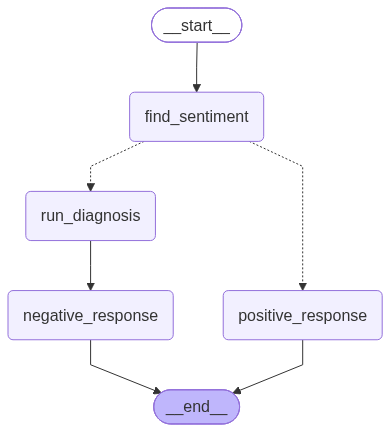

In [15]:
workflow

In [16]:
initial_state = {
    "review": """
        I honestly expected much more from this product. 
        The quality is surprisingly good in some areas, and I really liked how easy it was to use, 
        but at the same time, several things felt unnecessarily complicated and frustrating. 
        It works well when it works, although the occasional problems make me question whether I actually like it. 
        I wouldn't say it's bad, because there are definitely things I enjoyed, 
        but I can't confidently say it's good either. Maybe I'm being too critical, but for the price, 
        I expected something that wouldn't leave me this unsure about how I feel.
        """
}

result = workflow.invoke(initial_state)

In [17]:
result

{'review': "\n        I honestly expected much more from this product. \n        The quality is surprisingly good in some areas, and I really liked how easy it was to use, \n        but at the same time, several things felt unnecessarily complicated and frustrating. \n        It works well when it works, although the occasional problems make me question whether I actually like it. \n        I wouldn't say it's bad, because there are definitely things I enjoyed, \n        but I can't confidently say it's good either. Maybe I'm being too critical, but for the price, \n        I expected something that wouldn't leave me this unsure about how I feel.\n        ",
 'sentiment': 'negative',
 'diagnosis': DiagnosisSchema(issue_type='UX', tone='frustrated', urgency='low'),
 'response': 'I’m really sorry you’re running into trouble—UX hiccups can be especially frustrating. Could you let me know a bit more about what’s happening? For example:\n\n- What device and browser are you using?  \n- Which